# Image Classification with Deep Learning

## Project Description
This project demonstrates a basic deep learning task for classifying images using neural networks.

The dataset contains images of different objects. The model learns patterns from the images and predicts their categories.

## Goals:
- Understand deep learning fundamentals.
- Work with image datasets.
- Train a neural network model.

## Used Tools:
- Python
- TensorFlow

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets

(train_images,train_labels),(test_images,test_labels)=datasets.cifar10.load_data()

print("Training images shape:",train_images.shape)
print("Test images shape:",test_images.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1049s 6us/step
Training images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

In [3]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


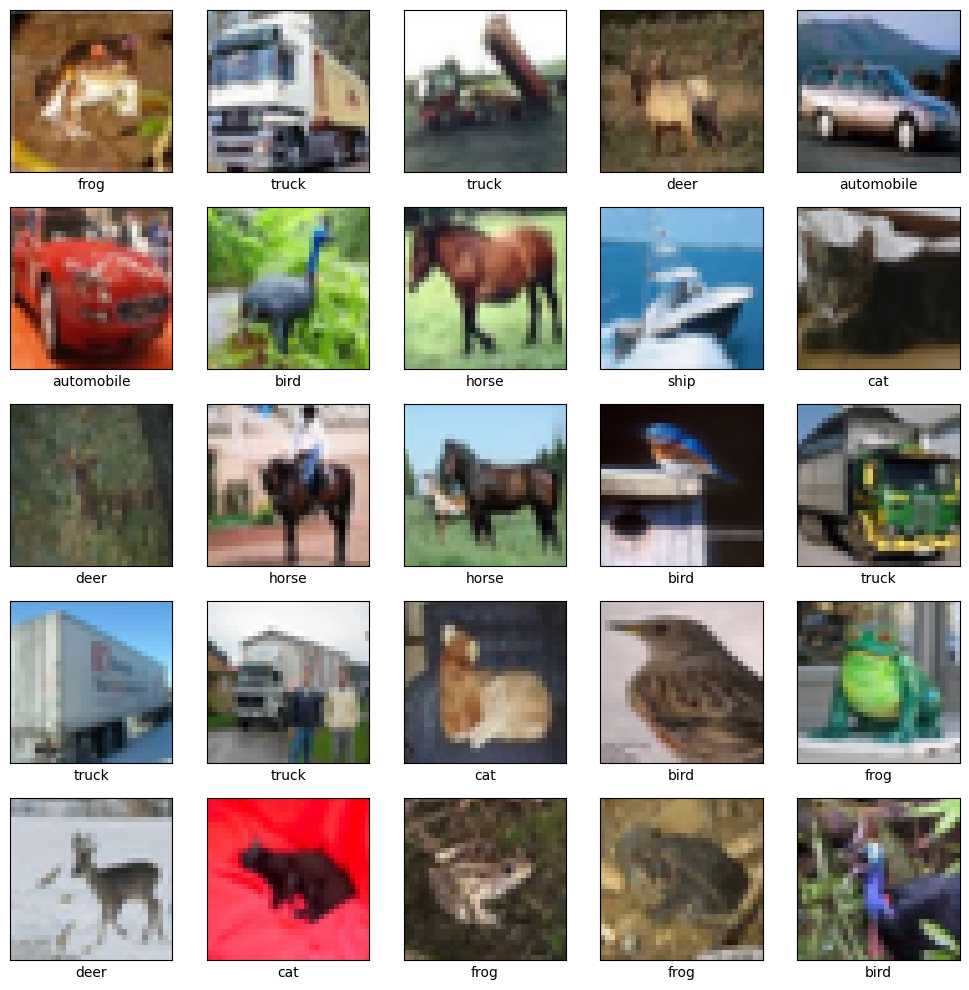

In [4]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])

plt.tight_layout()
plt.show()

In [5]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Minimum pixel value: 0.0

Maximum pixel value: 1.0

In [6]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.4103 - loss: 1.6110 - val_accuracy: 0.5097 - val_loss: 1.3761
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 40ms/step - accuracy: 0.5547 - loss: 1.2428 - val_accuracy: 0.5875 - val_loss: 1.1677
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.6121 - loss: 1.0911 - val_accuracy: 0.6251 - val_loss: 1.0595
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.6478 - loss: 0.9914 - val_accuracy: 0.6448 - val_loss: 1.0123
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.6767 - loss: 0.9149 - val_accuracy: 0.6655 - val_loss: 0.9517
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.6993 - loss: 0.8541 - val_accuracy: 0.6786 - val_loss: 0.9208
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7195 - loss: 0.8009 - val_accuracy: 0.6743 - val_loss: 0.9385
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 39ms/step - accuracy: 0.7358 -

In [9]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=2
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 - 4s - 11ms/step - accuracy: 0.6926 - loss: 0.9316
Test Accuracy: 69.26%
Test Loss: 0.9316


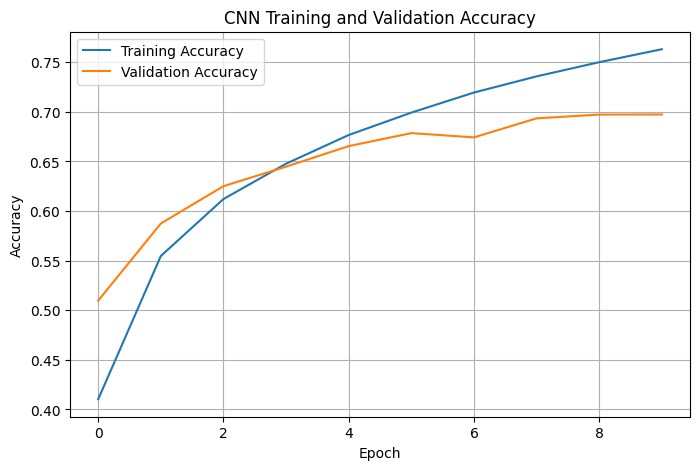

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

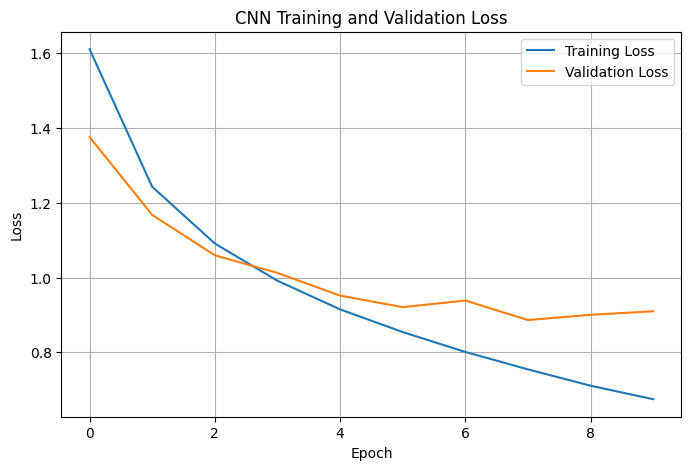

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
predictions = model.predict(test_images)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", class_names[predicted_labels[0]])
print("Actual:", class_names[test_labels[0][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Predicted: cat
Actual: cat


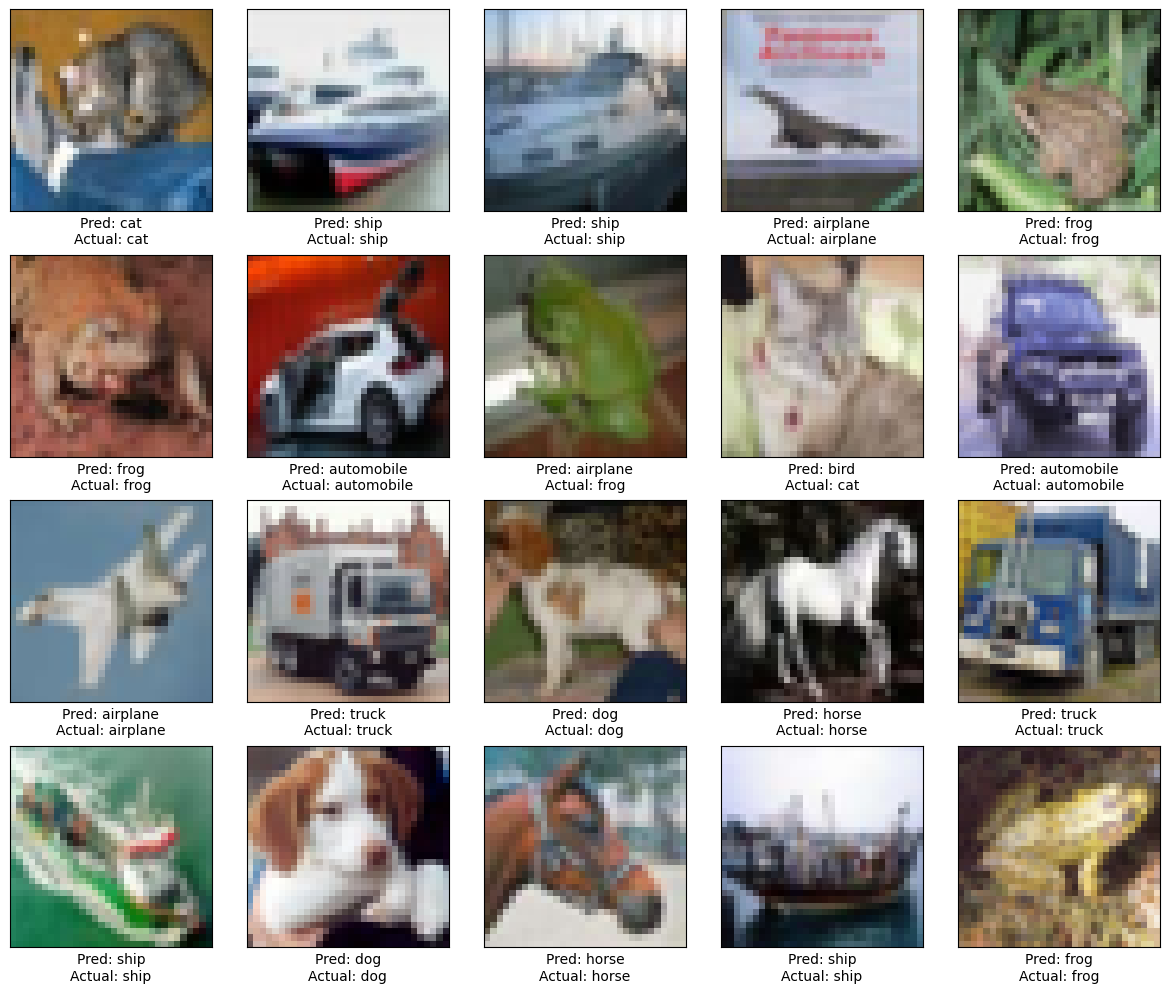

In [12]:
plt.figure(figsize=(12, 10))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(test_images[i])
    plt.xticks([])
    plt.yticks([])

    predicted = class_names[predicted_labels[i]]
    actual = class_names[test_labels[i][0]]

    plt.xlabel(f"Pred: {predicted}\nActual: {actual}")

plt.tight_layout()
plt.show()

## Conclusion

In this project, a Convolutional Neural Network (CNN) was successfully
developed and trained to classify images from the CIFAR-10 dataset.

The model achieved approximately 69% accuracy on unseen test images.
Training and validation results were analyzed using accuracy and loss
curves, and the trained model was used to generate predictions on
individual test images.

The results demonstrate how convolutional neural networks can learn
visual features directly from image data and perform multi-class image
classification.

Future improvements could include data augmentation, dropout,
additional convolutional layers, and transfer learning to improve
classification accuracy.